Ursprüngliche Anzahl Zeilen: 6214
Nach Ausschluss von 'err': 6214 Zeilen

Verteilung der Labels:
                                        Label  Anzahl (absolut)  Anteil (%)
                                     Economic               428    6.887673
                       Capacity and resources               279    4.489862
                                     Morality               187    3.009334
                        Fairness and equality               195    3.138075
Legality, constitutionality and jurisprudence              1081   17.396202
           Policy prescription and evaluation              1355   21.805600
                         Crime and punishment               542    8.722240
                         Security and defense               468    7.531381
                            Health and safety               162    2.607016
                              Quality of life               333    5.358867
                            Cultural identity               263    

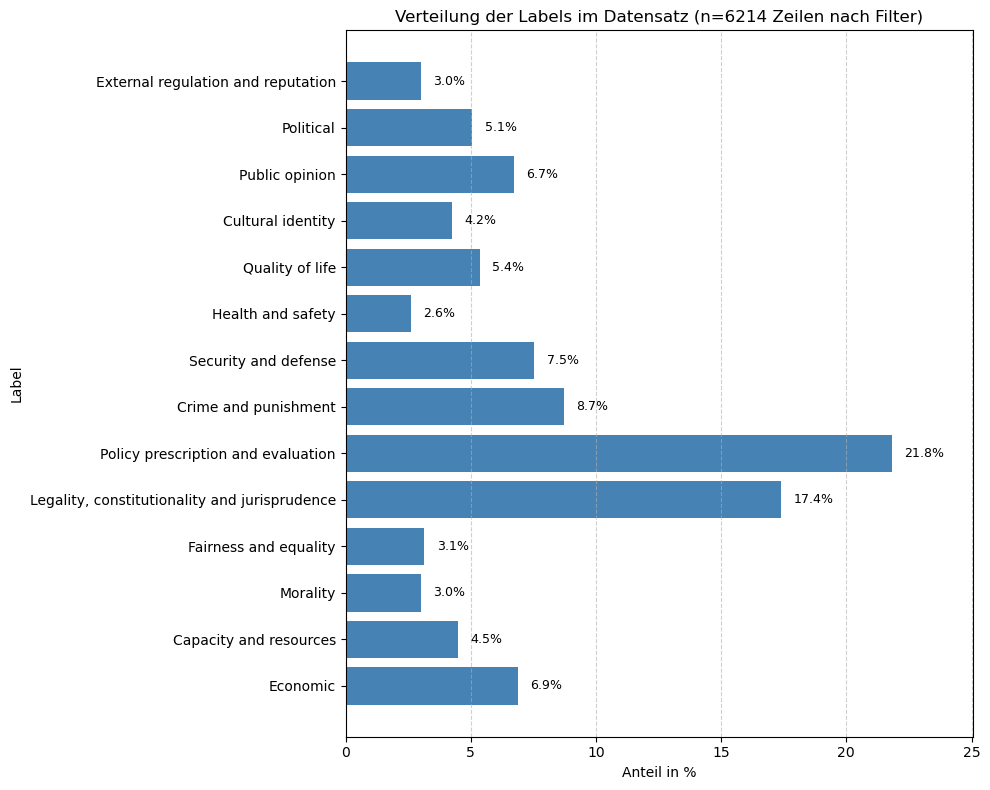


Top 5 Labels nach Häufigkeit:
                                        Label  Anteil (%)
           Policy prescription and evaluation   21.805600
Legality, constitutionality and jurisprudence   17.396202
                         Crime and punishment    8.722240
                         Security and defense    7.531381
                                     Economic    6.887673


In [1]:
# -*- coding: utf-8 -*-
"""
Notebook zur Analyse der Label-Verteilung im Datensatz.
Datei: mfc_stratified_sample_converted.xlsx
Zeilen mit Headline_GER == "err" werden ausgeschlossen.
Für jede der 14 Label-Spalten wird die absolute und relative Häufigkeit berechnet.
"""

import pandas as pd
import matplotlib.pyplot as plt

# 1. Daten einlesen (angepasster Dateiname)
file_path = "mfc_stratified_sample_converted.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 2. Zeilen mit "err" in der Spalte "Headline_GER" ausschließen
df_clean = df[df["Headline_GER"] != "err"].copy()

print(f"Ursprüngliche Anzahl Zeilen: {len(df)}")
print(f"Nach Ausschluss von 'err': {len(df_clean)} Zeilen")

# 3. Label-Spalten definieren (Spalten C bis P)
label_columns = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation"
]

# Sicherstellen, dass alle Spalten vorhanden sind
missing = [col for col in label_columns if col not in df_clean.columns]
if missing:
    print(f"Warnung: Folgende Spalten fehlen: {missing}")
    label_columns = [col for col in label_columns if col in df_clean.columns]

# 4. Häufigkeiten berechnen
abs_counts = df_clean[label_columns].sum()
rel_counts = (abs_counts / len(df_clean)) * 100

# 5. Ergebnisse tabellarisch anzeigen
results = pd.DataFrame({
    "Label": label_columns,
    "Anzahl (absolut)": abs_counts.values,
    "Anteil (%)": rel_counts.values
})
print("\nVerteilung der Labels:")
print(results.to_string(index=False))

# 6. Visualisierung mit matplotlib (horizontaler Balkenplot)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(label_columns, rel_counts.values, color='steelblue')

# Beschriftungen und Titel
ax.set_xlabel("Anteil in %")
ax.set_ylabel("Label")
ax.set_title(f"Verteilung der Labels im Datensatz (n={len(df_clean)} Zeilen nach Filter)")

# Werte an den Balkenenden anzeigen
for bar, value in zip(bars, rel_counts.values):
    ax.text(value + 0.5, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va='center', fontsize=9)

# Gitter für bessere Lesbarkeit
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_xlim(0, max(rel_counts) * 1.15)  # etwas Platz für Text

plt.tight_layout()
plt.show()

# 7. Top 5 Labels
print("\nTop 5 Labels nach Häufigkeit:")
top5 = results.sort_values("Anteil (%)", ascending=False).head(5)
print(top5[["Label", "Anteil (%)"]].to_string(index=False))